## Timing Analysis of the AXI4-MM

In this demo, we show how to analyze the timing.

## Pre-requisites

Before using this notebook, run:

```bash
python hist_demo.py --through generate_vcd --trace_level port [--live_output]
```

With the default `--start_at csim`, this runs the histogram flow through these stages:

- `csim`: C simulation
- `csynth`: C synthesis
- `cosim`: C/RTL co-simulation
- `generate_vcd`: re-run the RTL simulation to write a VCD file

You can also run the stages in smaller pieces. For example:

```bash
python hist_demo.py --through csynth [--live_output]
python hist_demo.py --start_at cosim --through generate_vcd --trace_level port [--live_output]
```

The first command runs C simulation and C synthesis.
The second command reuses the existing project, starts at RTL co-simulation, and then generates the VCD.

In [1]:
from vcdvcd import VCDVCD

# Check if VCD file exists
vcd_file = 'dump.vcd'
import os
fn = os.path.join(os.getcwd(), 'vcd', vcd_file)
if not os.path.exists(fn):
    raise FileNotFoundError(f"VCD file not found: {fn}")

# Parse the VCD file
vcd = VCDVCD(fn, signals=None, store_tvs=True)

In [7]:

from pysilicon.utils.vcd import VcdParser
from pysilicon.utils.timing import TimingDiagram

In [3]:
nsig = len(vcd.signals)
print(f"Number of signals in VCD: {nsig}")

# Find the signals with TDATA and TREADY in their names
prefix = 'm_axi_gmem_'
write_signals_lite = ['AWADDR', 'AWVALID', 'AWREADY', 'WDATA', 'WVALID', 'WREADY', 'BVALID', 'BREADY']
write_signals_full = ['AWLEN', 'WLAST']
sig = f"ADDR"
sigs = [s for s in vcd.signals if sig in s]
print(sigs)


Number of signals in VCD: 80
['apatb_hist_top.AESL_inst_hist.m_axi_gmem_AWADDR[63:0]', 'apatb_hist_top.AESL_inst_hist.m_axi_gmem_ARADDR[63:0]', 'apatb_hist_top.AESL_inst_hist.s_axi_control_AWADDR[4:0]', 'apatb_hist_top.AESL_inst_hist.s_axi_control_ARADDR[4:0]']


In [6]:
vp = VcdParser(vcd)
aximm_sigs, aximm_bw = vp.add_aximm_signals(prefix=prefix, dir='both', lite_only=False, short_name_prefix='gmem_')

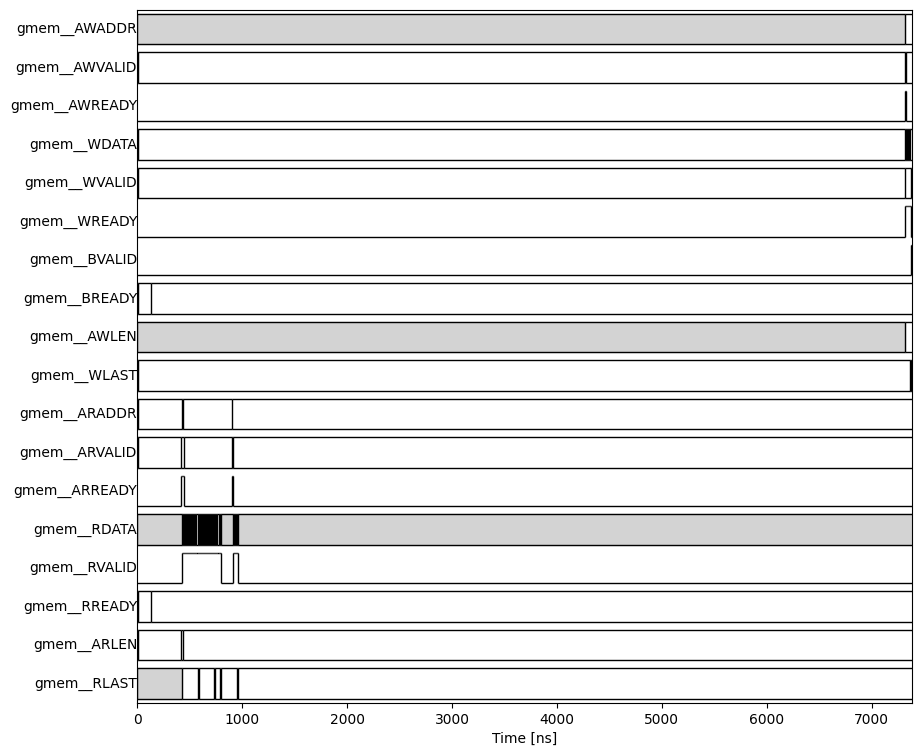

In [8]:
# Get the timing signals
sig_list = vp.get_td_signals()

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

In [14]:
s = 'gmem__WDATA'
si = td.sig_info[s]
si.times

array([0.000e+00, 5.000e+00, 7.315e+03, 7.325e+03, 7.335e+03, 7.345e+03,
       7.355e+03, 7.365e+03])